# Phase 1 Week 1 — Synthea Data Validation

## Overview

The cohort lives in `../data/raw/synthea_10000_bronze/fhir/` — the immutable Bronze snapshot of the 10,000-patient seed-42 cohort. Each patient bundle is a FHIR R4 `Bundle` whose `entry` list mixes `Patient`, `Encounter`, `Condition`, `Observation`, `MedicationRequest`, `Procedure`, etc. Two cohort-wide files (`hospitalInformation*.json`, `practitionerInformation*.json`) describe the synthetic providers and facilities all patients reference.

This notebook walks eight validation passes:

1. **Peek** at a single bundle to confirm structure.
2. **Stream** the cohort with a generator (avoids loading GBs of data into memory).
3. **Summarize**: resource-type counts, alive vs. deceased, age distribution, top conditions.
4. **Referential integrity**: every `urn:uuid:` reference resolves within its bundle.
5. **Temporal sanity**: encounter periods, condition ranges, and events fall within patient lifespans (with a § 5b drill-down into any violations).
6. **Resources-per-patient distribution**: per-patient counts of Conditions / Observations / MedicationRequests / Procedures / Encounters — catches generation pathologies and surfaces utilization outliers.
7. **Encounter class distribution**: IMP / AMB / EMER / etc. — informs how cleanly the cohort maps onto MIMIC-IV's ICU-heavy schema.
8. **Demographic distributions**: gender, race, ethnicity, age. Cohort-characterization baseline; also the strata for any later health-equity analysis.

Schema-mapping work (field inventory → MIMIC-IV target tables) lives in the sibling notebook `P1_Wk1_schema_mapping.ipynb`.

### Prerequisite

Per README, run `./scripts/generate_data.sh -p 10000` once to populate `data/raw/synthea_10000/`, then snapshot it as Bronze before any perturbation runs:

```bash
cp -r data/raw/synthea_10000 data/raw/synthea_10000_bronze
```

Validation reads from the Bronze snapshot so it stays green even after `src/pipeline/perturb_cohort.py` mutates the working copy in-place. The script uses Docker to run Synthea, but output is written directly to the host filesystem via a bind mount — Docker is not needed at notebook runtime.

In [1]:
import json
from collections import Counter
from datetime import date
from pathlib import Path

import pandas as pd

FHIR_DIR = Path("../data/raw/synthea_10000_bronze/fhir")

all_files = sorted(FHIR_DIR.glob("*.json"))
patient_files = [p for p in all_files if not p.name.startswith(("hospital", "practitioner"))]
cohort_files = [p.name for p in all_files if p.name.startswith(("hospital", "practitioner"))]

print(f"Patient bundles: {len(patient_files)}")
print(f"Cohort-wide files: {cohort_files}")

Patient bundles: 11490
Cohort-wide files: ['hospitalInformation1777860493399.json', 'practitionerInformation1777860493399.json']


## 1. Peek at a single bundle

In [2]:
with patient_files[0].open(encoding="utf-8") as f:
    bundle = json.load(f)

print(f"File: {patient_files[0].name}")
print(f"Top-level keys: {list(bundle.keys())}")
print(f"resourceType: {bundle['resourceType']}")
print(f"Entries: {len(bundle['entry'])}")

types_in_bundle = Counter(e["resource"]["resourceType"] for e in bundle["entry"])
print("\nResource types in this bundle:")
for rtype, n in types_in_bundle.most_common():
    print(f"  {rtype:25s} {n}")

File: Aaron697_Bosco882_a6b1639b-a2e1-abe3-0c15-ef67d7581e82.json
Top-level keys: ['resourceType', 'type', 'entry']
resourceType: Bundle
Entries: 1095

Resource types in this bundle:
  Observation               413
  Procedure                 162
  DiagnosticReport          120
  Claim                     76
  ExplanationOfBenefit      76
  Encounter                 56
  DocumentReference         56
  Condition                 51
  SupplyDelivery            24
  MedicationRequest         20
  Immunization              15
  Device                    8
  ImagingStudy              4
  Medication                4
  MedicationAdministration  4
  CareTeam                  2
  CarePlan                  2
  Patient                   1
  Provenance                1


## 2. Stream all bundles

A generator that yields `(path, bundle)` one at a time. Use this for any cohort-wide pass — it avoids holding GBs in memory simultaneously.

In [3]:
def iter_bundles(paths=None):
    paths = patient_files if paths is None else paths
    for p in paths:
        with p.open(encoding="utf-8") as fh:
            yield p, json.load(fh)

# Sanity check: every bundle should contain exactly one Patient resource.
missing_patient = []
multiple_patient = []
for path, bundle in iter_bundles():
    n_patients = sum(1 for e in bundle["entry"] if e["resource"]["resourceType"] == "Patient")
    if n_patients == 0:
        missing_patient.append(path.name)
    elif n_patients > 1:
        multiple_patient.append((path.name, n_patients))

print("Sanity check: every bundle should contain exactly one Patient resource.")
print(f"Bundles missing a Patient resource: {len(missing_patient)}")
print(f"Bundles with >1 Patient resource:    {len(multiple_patient)}")

Sanity check: every bundle should contain exactly one Patient resource.
Bundles missing a Patient resource: 0
Bundles with >1 Patient resource:    0


## 3. Cohort summary stats

Walks every bundle once and aggregates: resource-type counts, alive/deceased split, age distribution, and top conditions.
- This make take some time depending on number of bundles.

In [4]:
resource_counts = Counter()
alive = 0
deceased = 0
ages = []
condition_counts = Counter()

today = date.today()

for _, bundle in iter_bundles():
    for entry in bundle["entry"]:
        r = entry["resource"]
        rtype = r["resourceType"]
        resource_counts[rtype] += 1

        if rtype == "Patient":
            if r.get("deceasedDateTime"):
                deceased += 1
                end = date.fromisoformat(r["deceasedDateTime"][:10])
            else:
                alive += 1
                end = today
            birth = date.fromisoformat(r["birthDate"])
            ages.append((end - birth).days / 365.25)

        elif rtype == "Condition":
            code = r.get("code", {})
            label = code.get("text") or (code.get("coding", [{}])[0].get("display"))
            if label:
                condition_counts[label] += 1

print(f"Patients: alive={alive}, deceased={deceased}, total={alive + deceased}")

ages_s = pd.Series(ages)
print(
    f"\nAge at end-of-record (years): "
    f"mean={ages_s.mean():.1f}, median={ages_s.median():.1f}, "
    f"min={ages_s.min():.1f}, max={ages_s.max():.1f}"
)

print("\nTop 15 resource types across the cohort:")
for rtype, n in resource_counts.most_common(15):
    print(f"  {rtype:30s} {n:>8,}")

print("\nTop 15 conditions across the cohort:")
for cond, n in condition_counts.most_common(15):
    print(f"  {cond:50s} {n:>6,}")

Patients: alive=10000, deceased=1490, total=11490

Age at end-of-record (years): mean=42.4, median=42.7, min=0.0, max=110.9

Top 15 resource types across the cohort:
  Observation                    6,155,197
  Procedure                      1,909,067
  DiagnosticReport               1,384,708
  Claim                          1,304,621
  ExplanationOfBenefit           1,304,621
  Encounter                       693,739
  DocumentReference               693,739
  MedicationRequest               610,882
  Condition                       422,057
  SupplyDelivery                  302,934
  Medication                      218,202
  MedicationAdministration        218,202
  Immunization                    165,529
  Device                           66,774
  ImagingStudy                     55,016

Top 15 conditions across the cohort:
  Medication review due (situation)                  84,754
  Stress (finding)                                   33,152
  Gingivitis (disorder)                  

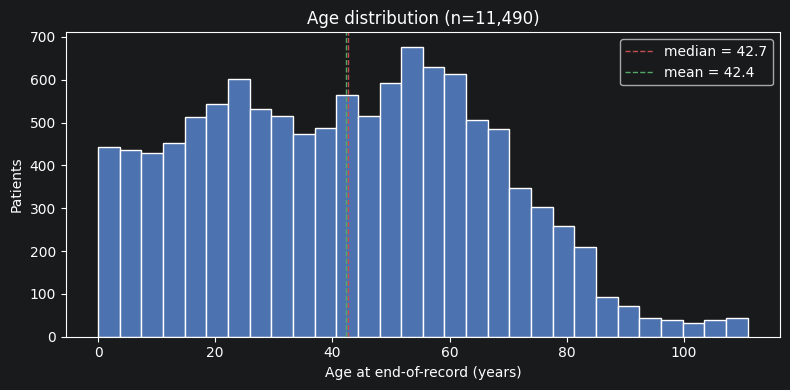

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(ages, bins=30, color="#4c72b0", edgecolor="white")
ax.axvline(ages_s.median(), color="#c44e52", linestyle="--", linewidth=1, label=f"median = {ages_s.median():.1f}")
ax.axvline(ages_s.mean(), color="#55a868", linestyle="--", linewidth=1, label=f"mean = {ages_s.mean():.1f}")
ax.set_xlabel("Age at end-of-record (years)")
ax.set_ylabel("Patients")
ax.set_title(f"Age distribution (n={len(ages):,})")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Referential integrity

Every `*.reference` should resolve. Synthea bundles use two reference styles:

- **Intra-bundle:** `"reference": "urn:uuid:<id>"` — must match a `fullUrl` of another entry in the **same** bundle.
- **Cohort-wide:** `"reference": "Practitioner?identifier=..."` or `"Organization?identifier=..."` — search-style refs to the hospital/practitioner files. We don't resolve these here (they go through Synthea's search mechanism, not direct ID lookup).

This pass walks every bundle and counts orphan `urn:uuid:` references. Zero is the only acceptable answer.

In [6]:
def walk_references(obj):
    """Yield every value of any `reference` key found anywhere in `obj`."""
    if isinstance(obj, dict):
        for k, v in obj.items():
            if k == "reference" and isinstance(v, str):
                yield v
            else:
                yield from walk_references(v)
    elif isinstance(obj, list):
        for item in obj:
            yield from walk_references(item)


total_refs = 0
urn_refs = 0
search_refs = 0
other_refs = 0
orphans = []  # list of (bundle_name, reference) for unresolved urn:uuid refs

for path, bundle in iter_bundles():
    bundle_ids = {e.get("fullUrl") for e in bundle["entry"] if e.get("fullUrl")}
    for ref in walk_references(bundle):
        total_refs += 1
        if ref.startswith("urn:uuid:"):
            urn_refs += 1
            if ref not in bundle_ids:
                orphans.append((path.name, ref))
        elif "?" in ref:
            search_refs += 1  # cohort-wide search-style ref, not resolved here
        else:
            other_refs += 1

print(f"References scanned:   {total_refs:>10,}")
print(f"  urn:uuid (intra):   {urn_refs:>10,}  -> orphans: {len(orphans):,}")
print(f"  search-style:       {search_refs:>10,}  (cohort-wide; not resolved)")
print(f"  other:              {other_refs:>10,}")

if orphans:
    print(f"\nFirst 5 orphans:")
    for bundle_name, ref in orphans[:5]:
        print(f"  {bundle_name}: {ref}")
else:
    print("\nAll intra-bundle references resolve.")

References scanned:   77,101,971
  urn:uuid (intra):   58,527,336  -> orphans: 0
  search-style:       15,965,393  (cohort-wide; not resolved)
  other:               2,609,242

All intra-bundle references resolve.


## 5. Temporal sanity

Spot-check a few date-consistency invariants. Synthea is mostly well-behaved, but cheap to verify:

- **Encounter:** `period.start <= period.end`.
- **Condition:** `onsetDateTime <= abatementDateTime` (when both are present).
- **Patient lifespan:** every `Encounter.period.start` should fall between the patient's `birthDate` and `deceasedDateTime` (or today, if alive).

In [7]:
def parse_dt(s):
    """Parse the date portion of an ISO-8601 string. Synthea uses both `YYYY-MM-DD` and full datetimes."""
    return date.fromisoformat(s[:10]) if s else None


encounter_bad_period = []      # period.start > period.end
condition_bad_range = []       # onset > abatement
encounter_outside_life = []    # encounter outside [birth, end-of-record]

for path, bundle in iter_bundles():
    # Find the Patient first to get the lifespan window.
    patient = next((e["resource"] for e in bundle["entry"]
                    if e["resource"]["resourceType"] == "Patient"), None)
    birth = parse_dt(patient.get("birthDate")) if patient else None
    death = parse_dt(patient.get("deceasedDateTime")) if patient else None
    end = death or date.today()

    for entry in bundle["entry"]:
        r = entry["resource"]
        rtype = r["resourceType"]

        if rtype == "Encounter":
            period = r.get("period", {})
            start = parse_dt(period.get("start"))
            stop = parse_dt(period.get("end"))
            if start and stop and start > stop:
                encounter_bad_period.append((path.name, r["id"], start, stop))
            if start and birth and (start < birth or start > end):
                encounter_outside_life.append((path.name, r["id"], start, birth, end))

        elif rtype == "Condition":
            onset = parse_dt(r.get("onsetDateTime"))
            abate = parse_dt(r.get("abatementDateTime"))
            if onset and abate and onset > abate:
                condition_bad_range.append((path.name, r["id"], onset, abate))

print(f"Encounter period.start > period.end:      {len(encounter_bad_period):>6,}")
print(f"Condition onset > abatement:              {len(condition_bad_range):>6,}")
print(f"Encounters outside patient lifespan:      {len(encounter_outside_life):>6,}")

for label, sample in [("encounter bad period", encounter_bad_period),
                      ("condition bad range", condition_bad_range),
                      ("encounter outside life", encounter_outside_life)]:
    if sample:
        print(f"\nFirst 3 {label}:")
        for row in sample[:3]:
            print(f"  {row}")

Encounter period.start > period.end:           0
Condition onset > abatement:                   0
Encounters outside patient lifespan:       1,371

First 3 encounter outside life:
  ('Aaron697_Stracke611_ceb9356f-b7d8-a8d5-8d25-9471e871a51b.json', 'ceb9356f-b7d8-a8d5-764f-eace6bb1c185', datetime.date(2011, 7, 22), datetime.date(1955, 8, 12), datetime.date(2011, 7, 19))
  ("Abbie917_Lakesha141_O'Keefe54_71789ebb-bffb-29f8-35d8-e27f648d78b2.json", '71789ebb-bffb-29f8-fc12-b376d4fa0ec9', datetime.date(2013, 10, 6), datetime.date(1974, 8, 25), datetime.date(2013, 9, 27))
  ('Abdul218_Heathcote539_95960a09-41ea-98a1-bfc6-9ecc67e79dc6.json', '95960a09-41ea-98a1-00b2-1d25ad2330de', datetime.date(2009, 1, 17), datetime.date(1966, 5, 28), datetime.date(2009, 1, 6))


### 5b. Drill into encounters outside the lifespan

Splits the violations into *before birth* vs *after death*, shows the day-offset distribution, and surfaces the most common encounter classes / types / reasons. Synthea sometimes emits encounters shortly after `deceasedDateTime` (death-certificate flow, post-mortem-style follow-ups) — those should cluster within a few days of death. Anything far from the lifespan window, or *before* birth, is a red flag.

Note: Real MIMIC-IV doesn't have post-mortem encounters, so for fidelity to the target schema, we may want to drop  (period.start > deceasedDateTime).

In [8]:
if not encounter_outside_life:
    print("No violations to drill into.")
else:
    # Re-read only bundles known to contain a violator, and pull the full Encounter resource.
    violator_keys = {(fn, eid) for fn, eid, *_ in encounter_outside_life}
    violator_files = {fn for fn, _ in violator_keys}
    affected_paths = [p for p in patient_files if p.name in violator_files]

    details = []  # (side, days_off, file, encounter, birth, death)
    for path, bundle in iter_bundles(affected_paths):
        patient = next((e["resource"] for e in bundle["entry"]
                        if e["resource"]["resourceType"] == "Patient"), None)
        birth = parse_dt(patient.get("birthDate"))
        death = parse_dt(patient.get("deceasedDateTime"))
        end = death or date.today()
        for entry in bundle["entry"]:
            r = entry["resource"]
            if r["resourceType"] != "Encounter":
                continue
            if (path.name, r["id"]) not in violator_keys:
                continue
            start = parse_dt(r.get("period", {}).get("start"))
            if start < birth:
                side, days = "before_birth", (birth - start).days
            else:
                side, days = "after_death", (start - end).days
            details.append((side, days, path.name, r, birth, death))

    sides = Counter(d[0] for d in details)
    print(f"Total violations: {len(details)}")
    for side, n in sides.most_common():
        print(f"  {side}: {n}")

    for side in ("before_birth", "after_death"):
        offsets = [d[1] for d in details if d[0] == side]
        if not offsets:
            continue
        s = pd.Series(offsets)
        print(f"\n{side} day-offset (days past lifespan):")
        print(f"  min={s.min()}, p25={s.quantile(0.25):.0f}, median={s.median():.0f}, "
              f"p75={s.quantile(0.75):.0f}, max={s.max()}")

    class_counts = Counter()
    type_counts = Counter()
    reason_counts = Counter()
    for _, _, _, enc, _, _ in details:
        class_counts[enc.get("class", {}).get("code", "(none)")] += 1
        types = enc.get("type", [])
        if types:
            type_counts[types[0].get("text", "(none)")] += 1
        reasons = enc.get("reasonCode", [])
        if reasons and reasons[0].get("coding"):
            reason_counts[reasons[0]["coding"][0].get("display", "(none)")] += 1

    print("\nEncounter class.code:")
    for code, n in class_counts.most_common():
        print(f"  {code:10s} {n:>5,}")

    print("\nEncounter type.text (top 5):")
    for label, n in type_counts.most_common(5):
        print(f"  {label[:60]:60s} {n:>5,}")

    print("\nreasonCode display (top 5; encounters with no reasonCode are not counted):")
    for label, n in reason_counts.most_common(5):
        print(f"  {label[:60]:60s} {n:>5,}")

    print("\nTop 5 most-extreme cases by day-offset:")
    for side, days, fn, enc, birth, death in sorted(details, key=lambda x: -x[1])[:5]:
        cls = enc.get("class", {}).get("code", "?")
        types = enc.get("type", [])
        type_text = types[0].get("text", "?") if types else "?"
        print(f"  {side:13s} {days:>4}d  {cls:5s}  {type_text[:40]:40s}  birth={birth} death={death}")

Total violations: 1371
  after_death: 1371

after_death day-offset (days past lifespan):
  min=1, p25=3, median=5, p75=9, max=14

Encounter class.code:
  AMB        1,371

Encounter type.text (top 5):
  Death Certification                                          1,362
  Patient encounter procedure (procedure)                          3
  Encounter for check up (procedure)                               2
  Well child visit (procedure)                                     1
  Urgent care clinic (environment)                                 1

reasonCode display (top 5; encounters with no reasonCode are not counted):
  Chronic congestive heart failure (disorder)                    277
  End-stage renal disease (disorder)                             157
  Acute ST segment elevation myocardial infarction (disorder)    119
  Sudden cardiac death (disorder)                                118
  Pulmonary emphysema (disorder)                                  79

Top 5 most-extreme cases by day-

## 6. Resources-per-patient distribution

How many Conditions, Observations, MedicationRequests, Procedures, and Encounters does each patient carry? Catches generation pathologies — a patient with 0 conditions or 50× the median is either a model bug or a heavy-utilization edge case worth tagging.

In [9]:
from collections import defaultdict


TRACKED_TYPES = ["Condition", "Observation", "MedicationRequest", "Procedure", "Encounter"]

# patient_id -> resource_type -> count
per_patient = defaultdict(lambda: Counter())
patient_names = {}  # patient_id -> file name (for outlier reporting)

for path, bundle in iter_bundles():
    patient = next((e["resource"] for e in bundle["entry"]
                    if e["resource"]["resourceType"] == "Patient"), None)
    if not patient:
        continue
    pid = patient["id"]
    patient_names[pid] = path.name
    for entry in bundle["entry"]:
        rtype = entry["resource"]["resourceType"]
        if rtype in TRACKED_TYPES:
            per_patient[pid][rtype] += 1

print(f"{'resource':18s} {'mean':>8s} {'median':>7s} {'p99':>7s} {'max':>7s} {'zero':>6s}")
print("-" * 60)
for rtype in TRACKED_TYPES:
    counts = pd.Series([per_patient[pid][rtype] for pid in patient_names])
    print(f"{rtype:18s} {counts.mean():>8.1f} {counts.median():>7.0f} "
          f"{counts.quantile(0.99):>7.0f} {counts.max():>7.0f} {(counts == 0).sum():>6,}")

print("\nTop 5 outliers per resource type (highest count):")
for rtype in TRACKED_TYPES:
    ranked = sorted(patient_names, key=lambda pid: per_patient[pid][rtype], reverse=True)[:5]
    print(f"\n{rtype}:")
    for pid in ranked:
        n = per_patient[pid][rtype]
        print(f"  {n:>6,}  {patient_names[pid]}")

resource               mean  median     p99     max   zero
------------------------------------------------------------
Condition              36.7      29     230     498      0
Observation           535.7     174    6603   19511      0
MedicationRequest      53.2      11     737    3940    290
Procedure             166.2     114    1204    2180     16
Encounter              60.4      36     578     838      0

Top 5 outliers per resource type (highest count):

Condition:
     498  Esteban536_Littel644_e466b3b6-9348-5c96-b8ba-a6aa621b0d3e.json
     493  Ivory697_Goyette777_193948ef-73e1-492f-c8e8-25798de28e56.json
     491  Jen355_Olivia294_Runte676_d2b50ac7-e88f-02f8-6bb9-a50047d3b552.json
     489  Tad831_Yundt842_64e638ab-b7e9-f8dc-fa30-2f9a78373b85.json
     485  Billy698_Bartell116_35b79f76-37de-430b-ac19-1a005ee2d147.json

Observation:
  19,511  Ivory697_Goyette777_193948ef-73e1-492f-c8e8-25798de28e56.json
  18,281  Jen355_Olivia294_Runte676_d2b50ac7-e88f-02f8-6bb9-a50047d3b552.

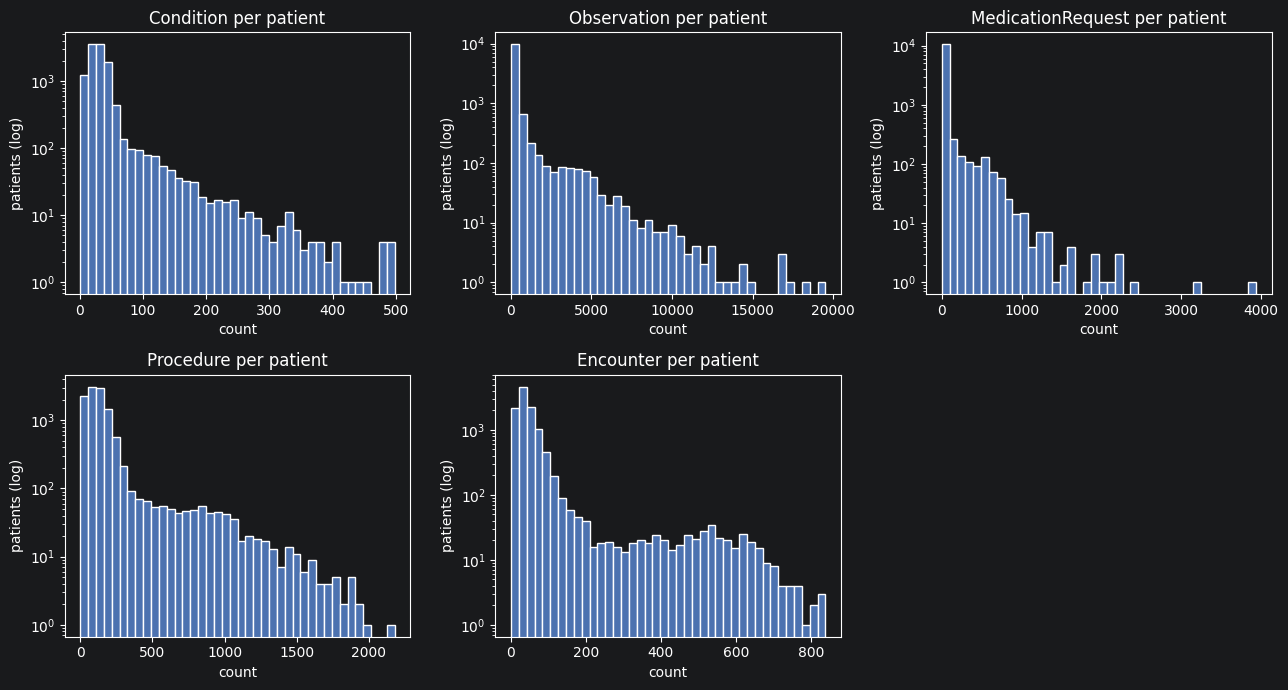

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
axes = axes.flatten()

for ax, rtype in zip(axes, TRACKED_TYPES):
    counts = [per_patient[pid][rtype] for pid in patient_names]
    ax.hist(counts, bins=40, color="#4c72b0", edgecolor="white")
    ax.set_yscale("log")  # heavy right-skew, log-scale makes outliers visible
    ax.set_title(f"{rtype} per patient")
    ax.set_xlabel("count")
    ax.set_ylabel("patients (log)")

# Hide the unused 6th subplot.
axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

## 7. Encounter class distribution

`Encounter.class.code` is the FHIR ActCode — `IMP` (inpatient), `AMB` (ambulatory), `EMER` (emergency), `WELLNESS`, etc. This matters because **MIMIC-IV is ICU-heavy**; if Synthea generates mostly outpatient/ambulatory encounters, the mapping into `mimiciv_icu.icustays` will be sparse and a structural realism gap opens up that should be acknowledged in the paper.

Reference: [HL7 v3 ActEncounterCode](https://www.hl7.org/fhir/v3/ActEncounterCode/vs.html).

In [11]:
class_counts = Counter()
type_counts = Counter()

for _, bundle in iter_bundles():
    for entry in bundle["entry"]:
        r = entry["resource"]
        if r["resourceType"] != "Encounter":
            continue
        class_counts[r.get("class", {}).get("code", "(none)")] += 1
        types = r.get("type", [])
        if types:
            type_counts[types[0].get("text", "(none)")] += 1

total = sum(class_counts.values())
print(f"Encounter.class.code distribution ({total:,} total encounters):\n")
print(f"{'code':10s} {'count':>10s} {'pct':>7s}")
print("-" * 32)
for code, n in class_counts.most_common():
    print(f"{code:10s} {n:>10,} {100*n/total:>6.1f}%")

print("\nEncounter.type[].text — top 15:")
for label, n in type_counts.most_common(15):
    print(f"  {n:>7,}  {label}")

# Flag the ICU-mappability concern explicitly.
icu_relevant = class_counts.get("IMP", 0) + class_counts.get("ACUTE", 0)
print(f"\nICU-mappable encounters (IMP + ACUTE): {icu_relevant:,} ({100*icu_relevant/total:.1f}%)")
print("Note: Synthea has no ICU-stay concept; even IMP encounters won't carry ICU-specific timeseries.")

Encounter.class.code distribution (693,739 total encounters):

code            count     pct
--------------------------------
AMB           646,967   93.3%
EMER           26,475    3.8%
IMP            13,021    1.9%
HH              5,496    0.8%
VR              1,780    0.3%

Encounter.type[].text — top 15:
  186,260  Encounter for problem (procedure)
  113,139  Encounter for check up (procedure)
  102,498  General examination of patient (procedure)
   37,591  Encounter for symptom (procedure)
   36,655  Well child visit (procedure)
   31,379  Urgent care clinic (environment)
   27,172  Prenatal visit (regime/therapy)
   20,518  Patient encounter procedure (procedure)
   20,473  Emergency room admission (procedure)
   17,178  Follow-up encounter (procedure)
   15,485  Outpatient procedure (procedure)
   13,255  Administration of vaccine to produce active immunity (procedure)
   12,458  Consultation for treatment (procedure)
   11,549  Telemedicine consultation with patient (procedure)


## 8. Demographic distributions  *(cohort characterization + health-equity baseline)*

Pure descriptive cuts of the cohort: gender, race, ethnicity, age. Main purposes:

1. **Sanity** — Synthea is calibrated to US population statistics, so distributions should look roughly like the US (with regional skew if the cohort was generated for a specific state).
2. **Health-equity baseline**

Race and ethnicity come from US-Core extensions on `Patient`:

- `http://hl7.org/fhir/us/core/StructureDefinition/us-core-race` → nested `ombCategory.valueCoding.display`
- `http://hl7.org/fhir/us/core/StructureDefinition/us-core-ethnicity` → same shape

**Caveat:** Synthea does not perfectly model real-world healthcare disparities.
Teeple, S., Muñoz, L. E., & Aysola, J. (2025). Synthetic data and health equity: Accounting for racism and sexism in health care delivery. Health Affairs Scholar, 3(9), qxaf165. https://doi.org/10.1093/haschl/qxaf165


In [12]:
US_CORE_RACE = "http://hl7.org/fhir/us/core/StructureDefinition/us-core-race"
US_CORE_ETHNICITY = "http://hl7.org/fhir/us/core/StructureDefinition/us-core-ethnicity"


def extract_us_core(patient, url):
    """Pull the `ombCategory.valueCoding.display` from a US-Core race/ethnicity extension."""
    for ext in patient.get("extension", []):
        if ext.get("url") != url:
            continue
        for sub in ext.get("extension", []):
            if sub.get("url") == "ombCategory":
                return sub.get("valueCoding", {}).get("display", "(unknown)")
        # Fall back to the `text` sub-extension if ombCategory absent.
        for sub in ext.get("extension", []):
            if sub.get("url") == "text":
                return sub.get("valueString", "(unknown)")
    return "(missing)"


def age_bucket(years):
    if years < 18: return "0-17"
    if years < 45: return "18-44"
    if years < 65: return "45-64"
    if years < 80: return "65-79"
    return "80+"


gender_counts = Counter()
race_counts = Counter()
ethnicity_counts = Counter()
age_counts = Counter()
deceased_by_race = defaultdict(lambda: {"alive": 0, "deceased": 0})
today = date.today()

for _, bundle in iter_bundles():
    patient = next((e["resource"] for e in bundle["entry"]
                    if e["resource"]["resourceType"] == "Patient"), None)
    if not patient:
        continue
    gender = patient.get("gender", "(unknown)")
    race = extract_us_core(patient, US_CORE_RACE)
    ethn = extract_us_core(patient, US_CORE_ETHNICITY)
    birth = date.fromisoformat(patient["birthDate"])
    death = patient.get("deceasedDateTime")
    end = date.fromisoformat(death[:10]) if death else today
    age_years = (end - birth).days / 365.25

    gender_counts[gender] += 1
    race_counts[race] += 1
    ethnicity_counts[ethn] += 1
    age_counts[age_bucket(age_years)] += 1
    deceased_by_race[race]["deceased" if death else "alive"] += 1

n = sum(gender_counts.values())


def show(label, counter, total):
    print(f"\n{label} (n={total:,}):")
    for k, v in counter.most_common():
        print(f"  {k:35s} {v:>5,}  {100*v/total:>5.1f}%")


show("Gender", gender_counts, n)
show("Race (US-Core ombCategory)", race_counts, n)
show("Ethnicity (US-Core ombCategory)", ethnicity_counts, n)

print("\nAge buckets (at end-of-record):")
for bucket in ["0-17", "18-44", "45-64", "65-79", "80+"]:
    v = age_counts.get(bucket, 0)
    print(f"  {bucket:8s} {v:>5,}  {100*v/n:>5.1f}%")

print("\nMortality by race (descriptive only; do not interpret causally):")
print(f"{'race':35s} {'alive':>7s} {'deceased':>9s} {'mortality':>10s}")
for race, splits in sorted(deceased_by_race.items(), key=lambda kv: -(kv[1]["alive"] + kv[1]["deceased"])):
    a, d = splits["alive"], splits["deceased"]
    tot = a + d
    print(f"  {race:33s} {a:>7,} {d:>9,} {100*d/tot:>9.1f}%")


Gender (n=11,490):
  female                              5,821   50.7%
  male                                5,669   49.3%

Race (US-Core ombCategory) (n=11,490):
  White                               9,455   82.3%
  Black or African American             977    8.5%
  Asian                                 737    6.4%
  Unknown                               139    1.2%
  Native Hawaiian or Other Pacific Islander   126    1.1%
  American Indian or Alaska Native       56    0.5%

Ethnicity (US-Core ombCategory) (n=11,490):
  Not Hispanic or Latino              10,260   89.3%
  Hispanic or Latino                  1,230   10.7%

Age buckets (at end-of-record):
  0-17     2,202   19.2%
  18-44    3,862   33.6%
  45-64    3,271   28.5%
  65-79    1,498   13.0%
  80+        657    5.7%

Mortality by race (descriptive only; do not interpret causally):
race                                  alive  deceased  mortality
  White                               8,216     1,239      13.1%
  Black or Afr

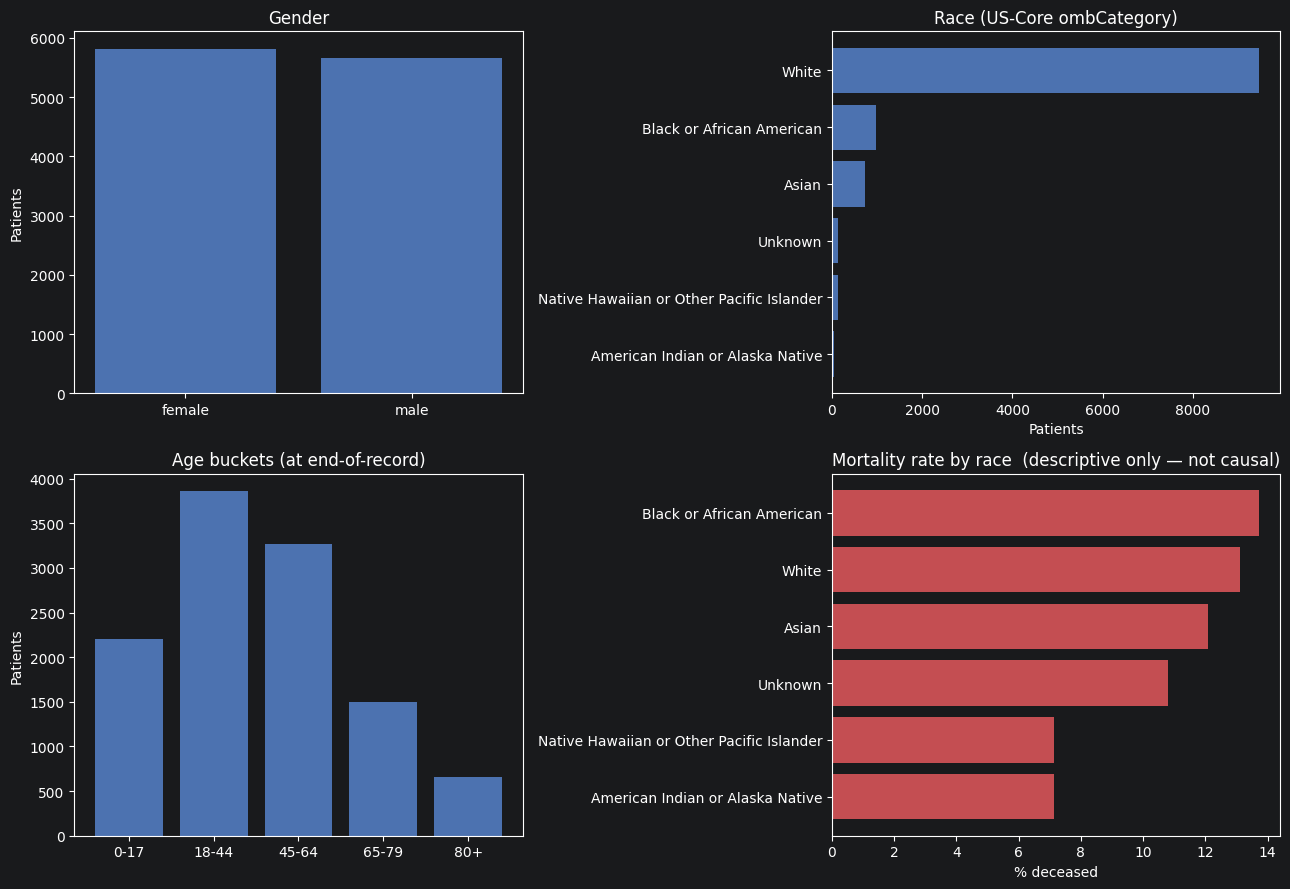

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# (a) Gender — vertical bar
ax = axes[0, 0]
labels, vals = zip(*gender_counts.most_common())
ax.bar(labels, vals, color="#4c72b0")
ax.set_title("Gender")
ax.set_ylabel("Patients")

# (b) Race — horizontal bar (longer labels)
ax = axes[0, 1]
labels, vals = zip(*race_counts.most_common())
ax.barh(labels, vals, color="#4c72b0")
ax.invert_yaxis()
ax.set_title("Race (US-Core ombCategory)")
ax.set_xlabel("Patients")

# (c) Age buckets — vertical bar in fixed order
ax = axes[1, 0]
buckets = ["0-17", "18-44", "45-64", "65-79", "80+"]
ax.bar(buckets, [age_counts.get(b, 0) for b in buckets], color="#4c72b0")
ax.set_title("Age buckets (at end-of-record)")
ax.set_ylabel("Patients")

# (d) Mortality rate by race — horizontal bar
ax = axes[1, 1]
items = []
for race, splits in deceased_by_race.items():
    tot = splits["alive"] + splits["deceased"]
    if tot == 0:
        continue
    items.append((race, 100 * splits["deceased"] / tot, tot))
items.sort(key=lambda r: r[1], reverse=True)
labels = [r[0] for r in items]
rates = [r[1] for r in items]
ax.barh(labels, rates, color="#c44e52")
ax.invert_yaxis()
ax.set_title("Mortality rate by race  (descriptive only — not causal)")
ax.set_xlabel("% deceased")

plt.tight_layout()
plt.show()